# Etap 3 — Modelowanie

**Zbiór bazowy do głównego toku:** `automl_std.csv` — imputacja przez H2O + standaryzacja.
Pełne porównanie wszystkich zbiorów na końcu notatnika.

## 1. Wczytanie danych i ręczny stratyfikowany podział train/test

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data/processed/final_datasets/automl_std.csv')

X = df.drop('Result', axis=1)
y = df['Result']

print(f"Wymiary calego zbioru: {X.shape}")
print(f"Rozklad klas w y:\n{y.value_counts().to_dict()}")

def manual_train_test_split(X, y, test_size=0.2, random_state=42):
    np.random.seed(random_state)
    y_arr = np.array(y)
    train_idx, test_idx = [], []

    for cls in np.unique(y_arr):
        cls_idx = np.where(y_arr == cls)[0]
        np.random.shuffle(cls_idx)
        k = int(len(cls_idx) * test_size)
        test_idx.extend(cls_idx[:k])
        train_idx.extend(cls_idx[k:])

    train_idx = np.array(train_idx)
    test_idx = np.array(test_idx)
    np.random.shuffle(train_idx)
    np.random.shuffle(test_idx)

    X_train = X.iloc[train_idx].reset_index(drop=True)
    X_test = X.iloc[test_idx].reset_index(drop=True)
    y_train = y.iloc[train_idx].reset_index(drop=True)
    y_test = y.iloc[test_idx].reset_index(drop=True)

    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = manual_train_test_split(X, y, test_size=0.2)

print(f"\nPodzial zakonczony sukcesem!")
print(f"Rozmiar zbioru treningowego (X_train): {len(X_train)} wierszy")
print(f"Rozmiar zbioru testowego  (X_test):  {len(X_test)} wierszy")
prop_train = {int(k): float(v) for k, v in y_train.value_counts(normalize=True).round(3).items()}
prop_test  = {int(k): float(v) for k, v in y_test.value_counts(normalize=True).round(3).items()}
print(f"Proporcje klas (train): {prop_train}")
print(f"Proporcje klas (test):  {prop_test}")


Wymiary calego zbioru: (11053, 20)
Rozklad klas w y:
{1.0: 6157, -1.0: 4895}

Podzial zakonczony sukcesem!
Rozmiar zbioru treningowego (X_train): 8842 wierszy
Rozmiar zbioru testowego  (X_test):  2210 wierszy
Proporcje klas (train): {1.0: np.float64(0.557), -1.0: np.float64(0.443)}
Proporcje klas (test):  {1.0: np.float64(0.557), -1.0: np.float64(0.443)}


## 2. Ręczna implementacja metryk + stratyfikowana k-fold CV + modele sklearn

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

def get_confusion_elements(y_true, y_pred, pos_label=1, neg_label=-1):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    TP = np.sum((y_true == pos_label) & (y_pred == pos_label))
    FP = np.sum((y_true == neg_label) & (y_pred == pos_label))
    TN = np.sum((y_true == neg_label) & (y_pred == neg_label))
    FN = np.sum((y_true == pos_label) & (y_pred == neg_label))
    return TP, FP, TN, FN


def manual_accuracy(y_true, y_pred):
    # SCIAGA: Accuracy = (TP+TN)/wszystko = jaki procent przewidywan jest poprawny.
    # SCIAGA: UWAGA: przy niezbalansowanych klasach myli! Np. 99% klasa "0" -> model
    # SCIAGA: ktory zawsze odpowiada "0" ma accuracy 99%, mimo ze jest bezuzyteczny.
    TP, FP, TN, FN = get_confusion_elements(y_true, y_pred)
    return (TP + TN) / (TP + FP + TN + FN) if (TP + FP + TN + FN) > 0 else 0.0


def manual_precision(y_true, y_pred):
    TP, FP, _, _ = get_confusion_elements(y_true, y_pred)
    return TP / (TP + FP) if (TP + FP) > 0 else 0.0


def manual_recall(y_true, y_pred):
    TP, _, _, FN = get_confusion_elements(y_true, y_pred)
    return TP / (TP + FN) if (TP + FN) > 0 else 0.0


def manual_f1_score(y_true, y_pred):
    precision = manual_precision(y_true, y_pred)
    recall = manual_recall(y_true, y_pred)
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

def manual_stratified_kfold(y, k=5, random_state=42):
    """Stratyfikowany podzial na k foldow - kazda klasa dzielona osobno na k czesci."""
    np.random.seed(random_state)
    y = np.array(y)
    unique_classes = np.unique(y)

    class_indices = {cls: np.where(y == cls)[0] for cls in unique_classes}
    for cls in class_indices:
        np.random.shuffle(class_indices[cls])

    folds_indices = [[] for _ in range(k)]
    for cls in class_indices:
        split_indices = np.array_split(class_indices[cls], k)
        for i in range(k):
            folds_indices[i].extend(split_indices[i])

    cv_splits = []
    all_indices = np.arange(len(y))
    for i in range(k):
        val_idx = np.array(folds_indices[i])
        train_idx = np.setdiff1d(all_indices, val_idx)
        cv_splits.append((train_idx, val_idx))

    return cv_splits

print("--- ROZPOCZECIE TRENOWANIA MODELI SCIKIT-LEARN ---")

models_sklearn = {
    "Regresja Logistyczna": LogisticRegression(max_iter=1000, random_state=42),
    "Drzewo Decyzyjne": DecisionTreeClassifier(random_state=42),
    "Las Losowy (Random Forest)": RandomForestClassifier(n_estimators=100, random_state=42),
    "Maszyna Wektorow Nosnych (SVM)": SVC(kernel='rbf', random_state=42, probability=True)
}

splits = manual_stratified_kfold(y_train, k=5)

results = []
for name, model in models_sklearn.items():
    print(f"\nTrenowanie: {name}...")

    cv_f1_scores = []
    for train_idx, val_idx in splits:
        X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
        model.fit(X_tr, y_tr)
        val_preds = model.predict(X_val)
        cv_f1_scores.append(manual_f1_score(y_val, val_preds))

    mean_cv_f1 = np.mean(cv_f1_scores)
    std_cv_f1 = np.std(cv_f1_scores)

    model.fit(X_train, y_train)
    test_preds = model.predict(X_test)

    results.append({
        "Model": name,
        "CV_F1_Mean": round(mean_cv_f1, 4),
        "CV_F1_Std": round(std_cv_f1, 4),
        "Test_Accuracy": round(manual_accuracy(y_test, test_preds), 4),
        "Test_Precision": round(manual_precision(y_test, test_preds), 4),
        "Test_Recall": round(manual_recall(y_test, test_preds), 4),
        "Test_F1": round(manual_f1_score(y_test, test_preds), 4)
    })

results_df = pd.DataFrame(results)
print("\n=== PODSUMOWANIE WYNIKOW (SCIKIT-LEARN) ===")
display(results_df.sort_values(by="Test_F1", ascending=False).reset_index(drop=True))


--- ROZPOCZECIE TRENOWANIA MODELI SCIKIT-LEARN ---

Trenowanie: Regresja Logistyczna...

Trenowanie: Drzewo Decyzyjne...

Trenowanie: Las Losowy (Random Forest)...



Trenowanie: Maszyna Wektorow Nosnych (SVM)...



=== PODSUMOWANIE WYNIKOW (SCIKIT-LEARN) ===


,Model,CV_F1_Mean,CV_F1_Std,Test_Accuracy,Test_Precision,Test_Recall,Test_F1
0,Las Losowy (Random Forest),0.9420,0.0047,0.9412,0.9429,0.9521,0.9475
1,Drzewo Decyzyjne,0.9261,0.0050,0.9235,0.9432,0.9180,0.9304
2,Maszyna Wektorow Nosnych (SVM),0.9353,0.0040,0.9199,0.9189,0.9391,0.9289
3,Regresja Logistyczna,0.9237,0.0062,0.9063,0.9031,0.9318,0.9172


## 3. Modele z innych bibliotek (XGBoost, LightGBM)

In [3]:
import xgboost as xgb
import lightgbm as lgb

print("--- ROZPOCZECIE TRENOWANIA MODELI Z INNYCH BIBLIOTEK ---")

y_train_gb = np.where(y_train == -1, 0, 1)
y_test_gb = np.where(y_test == -1, 0, 1)

models_external = {
    "XGBoost Classifier": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM Classifier": lgb.LGBMClassifier(random_state=42, verbose=-1)
}

external_results = []
for name, model in models_external.items():
    print(f"Trenowanie: {name}...")

    cv_f1_scores = []
    for train_idx, val_idx in splits:
        X_tr, y_tr_gb = X_train.iloc[train_idx], y_train_gb[train_idx]
        X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
        model.fit(X_tr, y_tr_gb)
        val_preds = model.predict(X_val)
        val_preds_mapped = np.where(val_preds == 0, -1, 1)
        cv_f1_scores.append(manual_f1_score(y_val, val_preds_mapped))

    mean_cv_f1 = np.mean(cv_f1_scores)
    std_cv_f1 = np.std(cv_f1_scores)

    model.fit(X_train, y_train_gb)
    test_preds = model.predict(X_test)
    test_preds_mapped = np.where(test_preds == 0, -1, 1)

    external_results.append({
        "Model": name,
        "CV_F1_Mean": round(mean_cv_f1, 4),
        "CV_F1_Std": round(std_cv_f1, 4),
        "Test_Accuracy": round(manual_accuracy(y_test, test_preds_mapped), 4),
        "Test_Precision": round(manual_precision(y_test, test_preds_mapped), 4),
        "Test_Recall": round(manual_recall(y_test, test_preds_mapped), 4),
        "Test_F1": round(manual_f1_score(y_test, test_preds_mapped), 4)
    })

external_df = pd.DataFrame(external_results)
final_results_df = pd.concat([results_df, external_df], ignore_index=True)

print("\n=== OSTATECZNE PODSUMOWANIE WSZYSTKICH MODELI ===")
display(final_results_df.sort_values(by="Test_F1", ascending=False).reset_index(drop=True))


--- ROZPOCZECIE TRENOWANIA MODELI Z INNYCH BIBLIOTEK ---
Trenowanie: XGBoost Classifier...


Trenowanie: LightGBM Classifier...



=== OSTATECZNE PODSUMOWANIE WSZYSTKICH MODELI ===


,Model,CV_F1_Mean,CV_F1_Std,Test_Accuracy,Test_Precision,Test_Recall,Test_F1
0,Las Losowy (Random Forest),0.9420,0.0047,0.9412,0.9429,0.9521,0.9475
1,XGBoost Classifier,0.9433,0.0030,0.9385,0.9426,0.9472,0.9449
2,LightGBM Classifier,0.9438,0.0011,0.9335,0.9378,0.9431,0.9405
3,Drzewo Decyzyjne,0.9261,0.0050,0.9235,0.9432,0.9180,0.9304
4,Maszyna Wektorow Nosnych (SVM),0.9353,0.0040,0.9199,0.9189,0.9391,0.9289
5,Regresja Logistyczna,0.9237,0.0062,0.9063,0.9031,0.9318,0.9172


## 4. Wizualizacja

--- GENEROWANIE WIZUALIZACJI KONCOWYCH ---


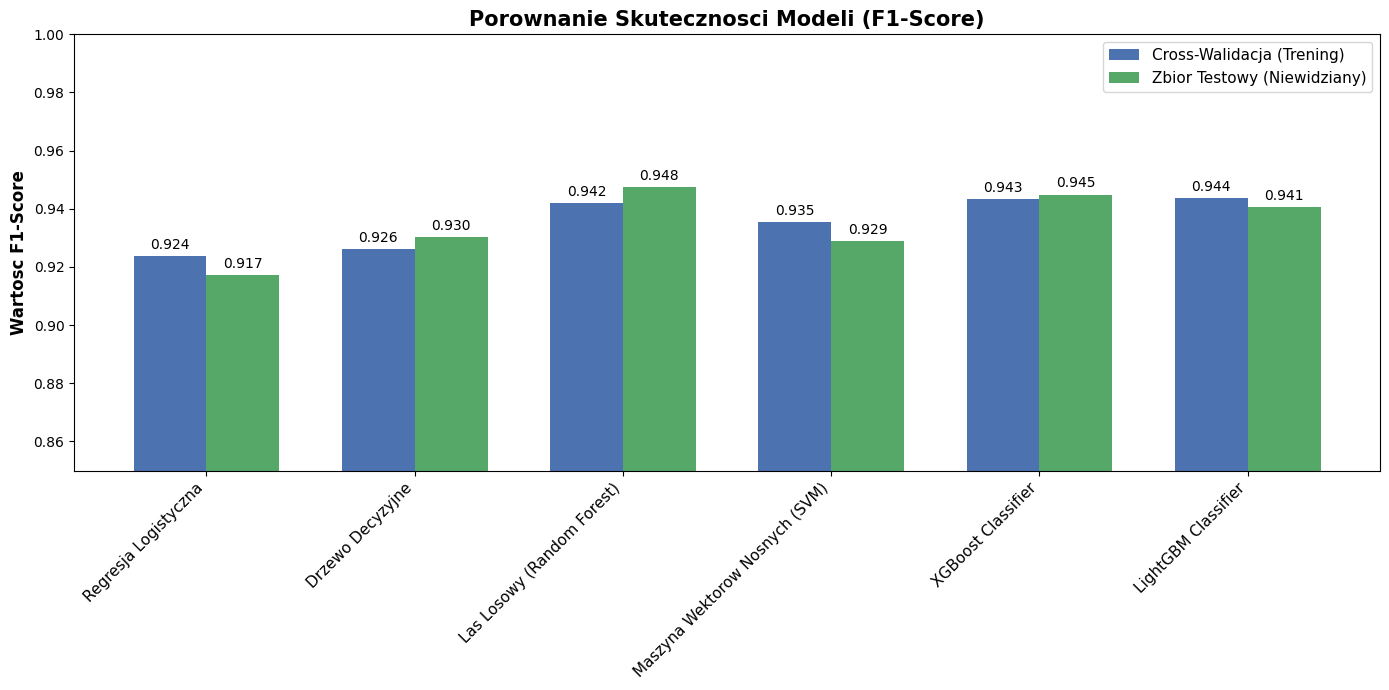


--- MACIERZ BLEDU DLA NAJLEPSZEGO MODELU (LAS LOSOWY) ---


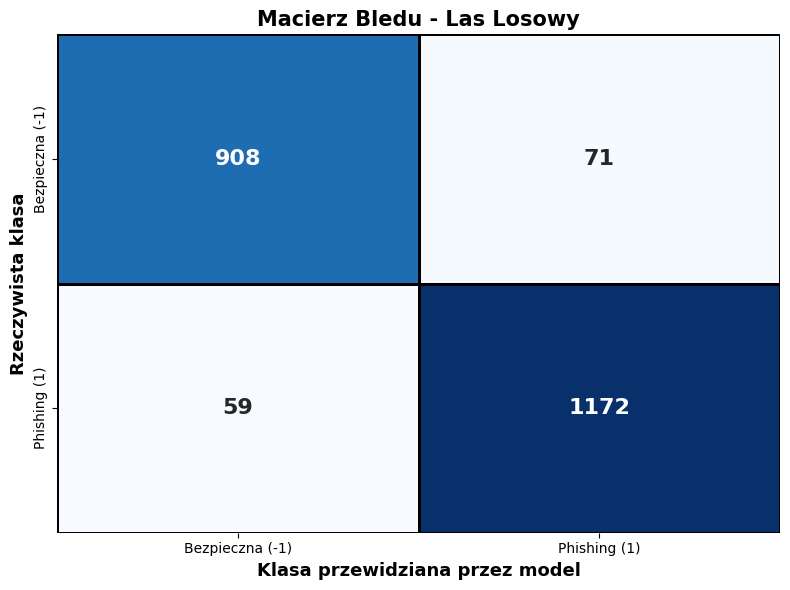


Interpretacja Macierzy Bledu:
1. Model poprawnie zablokowal 1172 atakow phishingowych (True Positives).
2. Model poprawnie przepuscil 908 bezpiecznych stron (True Negatives).
3. Model niepotrzebnie podniosl alarm dla 71 bezpiecznych stron (False Positives).
4. Model przepuscil 59 zlosliwych stron (False Negatives) - to najgrozniejszy typ bledu.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- GENEROWANIE WIZUALIZACJI KONCOWYCH ---")

models = final_results_df['Model']
cv_scores = final_results_df['CV_F1_Mean']
test_scores = final_results_df['Test_F1']

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
rects1 = ax.bar(x - width/2, cv_scores, width, label='Cross-Walidacja (Trening)', color='#4C72B0')
rects2 = ax.bar(x + width/2, test_scores, width, label='Zbior Testowy (Niewidziany)', color='#55A868')

ax.set_ylabel('Wartosc F1-Score', fontsize=12, fontweight='bold')
ax.set_title('Porownanie Skutecznosci Modeli (F1-Score)', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right', fontsize=11)
ax.set_ylim(0.85, 1.0)
ax.legend(fontsize=11)
ax.bar_label(rects1, padding=3, fmt='%.3f')
ax.bar_label(rects2, padding=3, fmt='%.3f')
plt.tight_layout()
plt.show()

print("\n--- MACIERZ BLEDU DLA NAJLEPSZEGO MODELU (LAS LOSOWY) ---")
best_model = models_sklearn["Las Losowy (Random Forest)"]
best_preds = best_model.predict(X_test)
TP, FP, TN, FN = get_confusion_elements(y_test, best_preds)
cm_matrix = np.array([[TN, FP], [FN, TP]])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bezpieczna (-1)', 'Phishing (1)'],
            yticklabels=['Bezpieczna (-1)', 'Phishing (1)'],
            annot_kws={"size": 16, "weight": "bold"},
            cbar=False, linewidths=1, linecolor='black')
plt.ylabel('Rzeczywista klasa', fontsize=13, fontweight='bold')
plt.xlabel('Klasa przewidziana przez model', fontsize=13, fontweight='bold')
plt.title('Macierz Bledu - Las Losowy', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInterpretacja Macierzy Bledu:")
print(f"1. Model poprawnie zablokowal {TP} atakow phishingowych (True Positives).")
print(f"2. Model poprawnie przepuscil {TN} bezpiecznych stron (True Negatives).")
print(f"3. Model niepotrzebnie podniosl alarm dla {FP} bezpiecznych stron (False Positives).")
print(f"4. Model przepuscil {FN} zlosliwych stron (False Negatives) - to najgrozniejszy typ bledu.")


## 5. Krzywe ROC i AUC dla wszystkich modeli

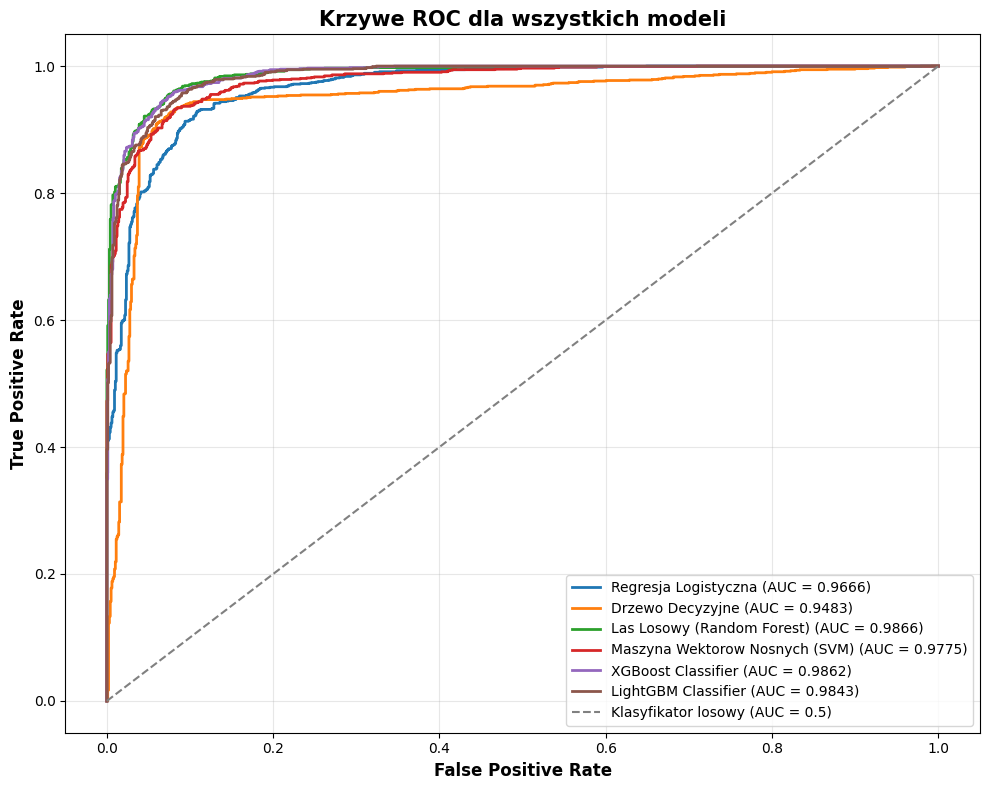

In [5]:
def manual_roc_curve(y_true, y_score, pos_label=1, neg_label=-1):
    """Zwraca (fpr_array, tpr_array, thresholds) dla klasyfikacji binarnej."""
    y_true = np.array(y_true)
    y_score = np.array(y_score)

    desc_order = np.argsort(-y_score)
    y_true_sorted = y_true[desc_order]
    y_score_sorted = y_score[desc_order]

    P = np.sum(y_true == pos_label)
    N = np.sum(y_true == neg_label)

    tps = np.cumsum(y_true_sorted == pos_label)
    fps = np.cumsum(y_true_sorted == neg_label)

    tpr = tps / P if P > 0 else np.zeros_like(tps, dtype=float)
    fpr = fps / N if N > 0 else np.zeros_like(fps, dtype=float)

    tpr = np.concatenate(([0.0], tpr))
    fpr = np.concatenate(([0.0], fpr))
    thresholds = np.concatenate(([np.inf], y_score_sorted))
    return fpr, tpr, thresholds


def manual_auc(fpr, tpr):
    """AUC metoda trapezow. np.trapezoid od NumPy 2.0, np.trapz dla starszych."""
    trapezoid = getattr(np, "trapezoid", None) or getattr(np, "trapz")
    return float(trapezoid(tpr, fpr))


plt.figure(figsize=(10, 8))

for name, model in models_sklearn.items():
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_test)[:, list(model.classes_).index(1)]
    else:
        scores = model.decision_function(X_test)
    fpr, tpr, _ = manual_roc_curve(y_test, scores, pos_label=1, neg_label=-1)
    auc = manual_auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})", linewidth=2)

for name, model in models_external.items():
    scores = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = manual_roc_curve(y_test_gb, scores, pos_label=1, neg_label=0)
    auc = manual_auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})", linewidth=2)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Klasyfikator losowy (AUC = 0.5)")
plt.xlabel("False Positive Rate", fontsize=12, fontweight="bold")
plt.ylabel("True Positive Rate", fontsize=12, fontweight="bold")
plt.title("Krzywe ROC dla wszystkich modeli", fontsize=15, fontweight="bold")
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Porównanie zbiorów danych

Znaleziono 8 zbiorow:
  - automl_minmax.csv
  - automl_std.csv
  - const_minmax.csv
  - const_std.csv
  - knn_minmax.csv
  - knn_std.csv
  - mode_minmax.csv
  - mode_std.csv



=== F1-Score na zbiorze testowym (wiersze = zbior danych, kolumny = model) ===


model,LightGBM,LogReg,RandomForest,sredni F1
dataset,,,,
knn_std,0.9470,0.9276,0.9480,0.9409
knn_minmax,0.9408,0.9267,0.9426,0.9367
automl_std,0.9405,0.9172,0.9475,0.9351
mode_std,0.9405,0.9172,0.9475,0.9351
automl_minmax,0.9423,0.9207,0.9405,0.9345
mode_minmax,0.9423,0.9207,0.9405,0.9345
const_std,0.9355,0.9157,0.9396,0.9303
const_minmax,0.9308,0.9169,0.9342,0.9273


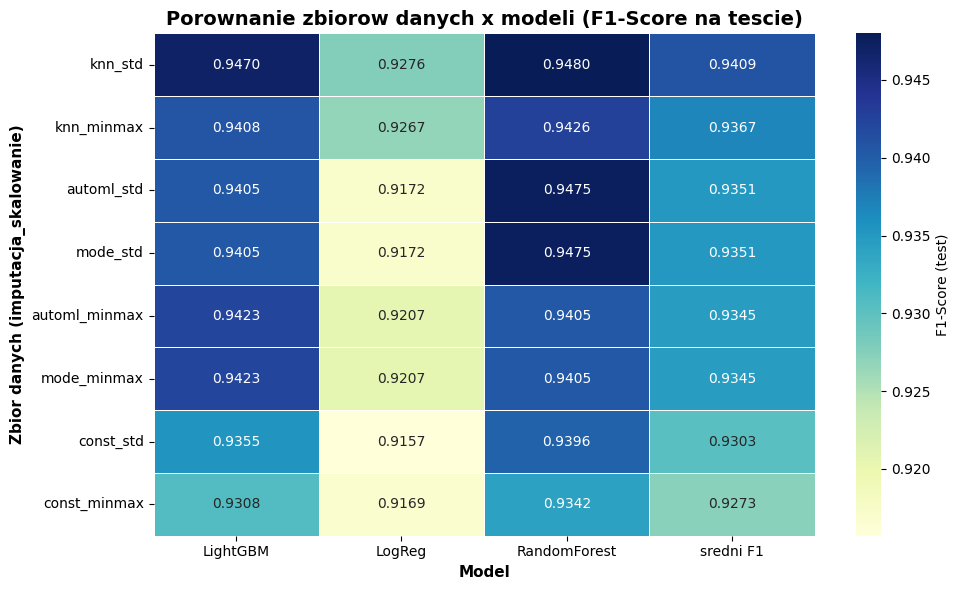


Najlepszy zbior wedlug sredniego F1: knn_std (sredni F1 = 0.9409)
W glownym toku Etapu 3 uzywano:        automl_std


In [6]:
import glob
import os

dataset_paths = sorted(glob.glob('data/processed/final_datasets/*.csv'))
print(f"Znaleziono {len(dataset_paths)} zbiorow:")
for p in dataset_paths:
    print(f"  - {os.path.basename(p)}")

comparison_models = {
    "LogReg": lambda: LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": lambda: RandomForestClassifier(n_estimators=100, random_state=42),
    "LightGBM": lambda: lgb.LGBMClassifier(random_state=42, verbose=-1),
}

comparison_rows = []
for path in dataset_paths:
    ds_name = os.path.basename(path).replace(".csv", "")
    ds = pd.read_csv(path)
    Xd, yd = ds.drop("Result", axis=1), ds["Result"]
    Xd_tr, Xd_te, yd_tr, yd_te = manual_train_test_split(Xd, yd, test_size=0.2)

    for m_name, m_factory in comparison_models.items():
        model = m_factory()
        if m_name == "LightGBM":
            yd_tr_use = np.where(yd_tr == -1, 0, 1)
            yd_te_use = np.where(yd_te == -1, 0, 1)
            model.fit(Xd_tr, yd_tr_use)
            preds = model.predict(Xd_te)
            preds_mapped = np.where(preds == 0, -1, 1)
            f1 = manual_f1_score(yd_te, preds_mapped)
        else:
            model.fit(Xd_tr, yd_tr)
            preds = model.predict(Xd_te)
            f1 = manual_f1_score(yd_te, preds)
        comparison_rows.append({"dataset": ds_name, "model": m_name, "f1": round(f1, 4)})

comparison_df = pd.DataFrame(comparison_rows)
pivot = comparison_df.pivot(index="dataset", columns="model", values="f1")
pivot["sredni F1"] = pivot.mean(axis=1).round(4)
pivot = pivot.sort_values(by="sredni F1", ascending=False)

print("\n=== F1-Score na zbiorze testowym (wiersze = zbior danych, kolumny = model) ===")
display(pivot)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlGnBu",
            cbar_kws={"label": "F1-Score (test)"}, linewidths=0.5, linecolor="white")
plt.title("Porownanie zbiorow danych x modeli (F1-Score na tescie)", fontsize=14, fontweight="bold")
plt.ylabel("Zbior danych (imputacja_skalowanie)", fontsize=11, fontweight="bold")
plt.xlabel("Model", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

best_dataset = pivot["sredni F1"].idxmax()
print(f"\nNajlepszy zbior wedlug sredniego F1: {best_dataset} (sredni F1 = {pivot.loc[best_dataset, 'sredni F1']:.4f})")
print(f"W glownym toku Etapu 3 uzywano:        automl_std")
